# Test 4: FAO-56 Crop Coefficient Curve Construction

This notebook verifies that the SWB2 date-based FAO-56 crop coefficient (Kcb) curve construction is consistent with a Python reimplementation of the same algorithm. The test uses the Minnesota PRISM domain with crop coefficient method enabled.

The FAO-56 Kcb curve is a trapezoidal function defined by:
- **Planting date** (DOY 122 = May 1 for Hay/Pasture)
- **Stage lengths**: l_ini=20, l_dev=30, l_mid=70, l_late=25, l_fallow=1 days
- **Kcb values**: kcb_ini=0.15, kcb_mid=0.95, kcb_end=0.50, kcb_min=0.15

## References

Allen, R.G., Pereira, L.S., Raes, D., and Smith, M., 1998, Crop evapotranspiration — Guidelines for computing crop water requirements: FAO Irrigation and Drainage Paper 56, 300 p.

## Test setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pathlib as pl
import sys
import subprocess
import datetime as dt

In [2]:
base_dir = str(pl.Path.cwd().parent)
python_script_dir = pl.Path.cwd().parent / 'python'
test_dir = pl.Path.cwd().parent / 'test__fao56_crop_coefficients'
logfile_dir = test_dir / 'logfiles'
test_data_dir = pl.Path.cwd().parent / 'test_data'
output_dir = test_dir / 'output'
swb2_executable = str(pl.Path.cwd().parent / 'bin' / 'swb2.exe')
sys.path.append(str(python_script_dir))

import run_management as rm
from crop_coefficients_fao56_date import (compute_growth_stage_dates,
                                          update_crop_coefficient_date,
                                          compute_kcb_timeseries)

## Run SWB2 with FAO-56 crop coefficients enabled

In [3]:
rm.destroy_model_work_output_and_logfile_dirs(base_dir=base_dir,
                                              test_dir=test_dir,
                                              logfile_dir=logfile_dir,
                                              output_dir=output_dir)
rm.create_model_work_output_and_logfile_dirs(base_dir=base_dir,
                                             test_dir=test_dir,
                                             logfile_dir=logfile_dir,
                                             output_dir=output_dir)

In [4]:
dry_run = False
lookup_dir_arg_text = f"--lookup_dir={str(test_data_dir)}"
weather_data_dir_arg_text = f"--weather_data_dir={str(test_data_dir)}"
data_dir_arg_text = f"--data_dir={str(test_data_dir)}"
output_dir_arg_text = f"--output_dir={str(output_dir)}"
logfile_dir_arg_text = f"--logfile_dir={str(logfile_dir)}"
control_file_path = str(test_data_dir / 'swb_control_file_fao56_crop_coeff.ctl')
output_prefix = '--output_prefix=swb_fao56_'

swb_arg_text = [swb2_executable,
                output_dir_arg_text,
                data_dir_arg_text,
                lookup_dir_arg_text,
                weather_data_dir_arg_text,
                output_prefix,
                logfile_dir_arg_text,
                control_file_path]

f = open("stdout.txt", "w")

if not dry_run:
    with rm.cd(test_dir):
        p = subprocess.Popen(swb_arg_text, stdout=f, stderr=subprocess.DEVNULL)
        p.wait()

print(f"SWB2 return code: {p.returncode}")

SWB2 return code: 0


## Read SWB2 output

In [5]:
swb_df = pd.read_csv(pl.Path(output_dir, 'SWB2_variable_values__US-Ro6__col_45__row_65__x_232693__y_2415326.csv'))
swb_df.columns = swb_df.columns.str.strip()
swb_df['date'] = pd.to_datetime(swb_df['date'])
print(f"Loaded {len(swb_df)} days of SWB2 output")
print(f"Land use code: {swb_df['landuse_code'].iloc[0]}")
print(f"Kcb range: {swb_df['crop_coefficient_kcb'].min():.4f} to {swb_df['crop_coefficient_kcb'].max():.4f}")

Loaded 2557 days of SWB2 output
Land use code: 81
Kcb range: 0.1500 to 0.9500


## Python Kcb curve construction

Parameters for land use code 81 (Hay/Pasture) from IRR_lookup_MN_v3.txt:

In [6]:
# Parameters from IRR lookup table for LU code 81 (Hay/Pasture)
PLANTING_DOY = 122   # May 1 (DOY 122 in non-leap year)
L_INI = 20
L_DEV = 30
L_MID = 70
L_LATE = 25
L_FALLOW = 1
KCB_INI = 0.15
KCB_MID = 0.95
KCB_END = 0.50
KCB_MIN = 0.15

start_date = swb_df['date'].iloc[0].date()
end_date = swb_df['date'].iloc[-1].date()

py_dates, py_kcb = compute_kcb_timeseries(
    start_date, end_date, PLANTING_DOY,
    L_INI, L_DEV, L_MID, L_LATE, L_FALLOW,
    KCB_INI, KCB_MID, KCB_END, KCB_MIN)

py_kcb = np.array(py_kcb)
print(f"Python Kcb range: {py_kcb.min():.4f} to {py_kcb.max():.4f}")
print(f"\nGrowth stage dates (year 1999):")
stages = compute_growth_stage_dates(dt.date(1999, 1, 1) + dt.timedelta(days=PLANTING_DOY-1),
                                    L_INI, L_DEV, L_MID, L_LATE, L_FALLOW)
for k, v in stages.items():
    print(f"  {k:12s}: {v} (DOY {v.timetuple().tm_yday})")

Python Kcb range: 0.1500 to 0.9500

Growth stage dates (year 1999):
  planting    : 1999-05-02 (DOY 122)
  end_ini     : 1999-05-22 (DOY 142)
  end_dev     : 1999-06-21 (DOY 172)
  end_mid     : 1999-08-30 (DOY 242)
  end_late    : 1999-09-24 (DOY 267)
  end_fallow  : 1999-09-25 (DOY 268)


## Comparison: Kcb timeseries

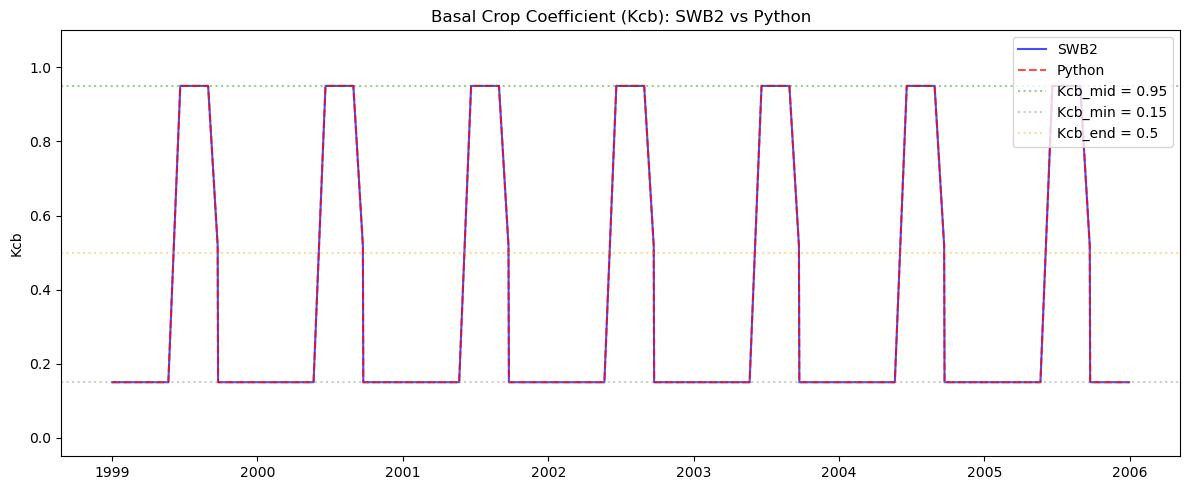

Max absolute difference: 0.000000
Mean absolute difference: 0.000000


In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(swb_df['date'], swb_df['crop_coefficient_kcb'], 'b-', label='SWB2', alpha=0.7)
ax.plot(py_dates, py_kcb, 'r--', label='Python', alpha=0.7)
ax.axhline(KCB_MID, color='green', linestyle=':', alpha=0.4, label=f'Kcb_mid = {KCB_MID}')
ax.axhline(KCB_MIN, color='gray', linestyle=':', alpha=0.4, label=f'Kcb_min = {KCB_MIN}')
ax.axhline(KCB_END, color='orange', linestyle=':', alpha=0.4, label=f'Kcb_end = {KCB_END}')
ax.set_ylabel('Kcb')
ax.set_title('Basal Crop Coefficient (Kcb): SWB2 vs Python')
ax.legend(loc='upper right')
ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()

diff = swb_df['crop_coefficient_kcb'] - py_kcb

print(f"Max absolute difference: {np.abs(diff).max():.6f}")
print(f"Mean absolute difference: {np.abs(diff).mean():.6f}")

## Detail: Single-year Kcb curve anatomy

Zoom into a single growing season to show the trapezoidal shape and growth stage boundaries.

Python stage dates for 2000:
  planting    : 2000-05-02 (DOY 123)
  end_ini     : 2000-05-22 (DOY 143)
  end_dev     : 2000-06-21 (DOY 173)
  end_mid     : 2000-08-30 (DOY 243)
  end_late    : 2000-09-24 (DOY 268)
  end_fallow  : 2000-09-25 (DOY 269)

--- SWB2 logfile Kcb curve messages: ---

SWB2 Kcb around end_ini (2000):
  2000-05-19  SWB2=0.1500  Py=0.1500
  2000-05-20  SWB2=0.1500  Py=0.1500
  2000-05-21  SWB2=0.1500  Py=0.1500
  2000-05-22  SWB2=0.1767  Py=0.1767
  2000-05-23  SWB2=0.2033  Py=0.2033
  2000-05-24  SWB2=0.2300  Py=0.2300
  2000-05-25  SWB2=0.2567  Py=0.2567
  2000-05-26  SWB2=0.2833  Py=0.2833
  2000-05-27  SWB2=0.3100  Py=0.3100


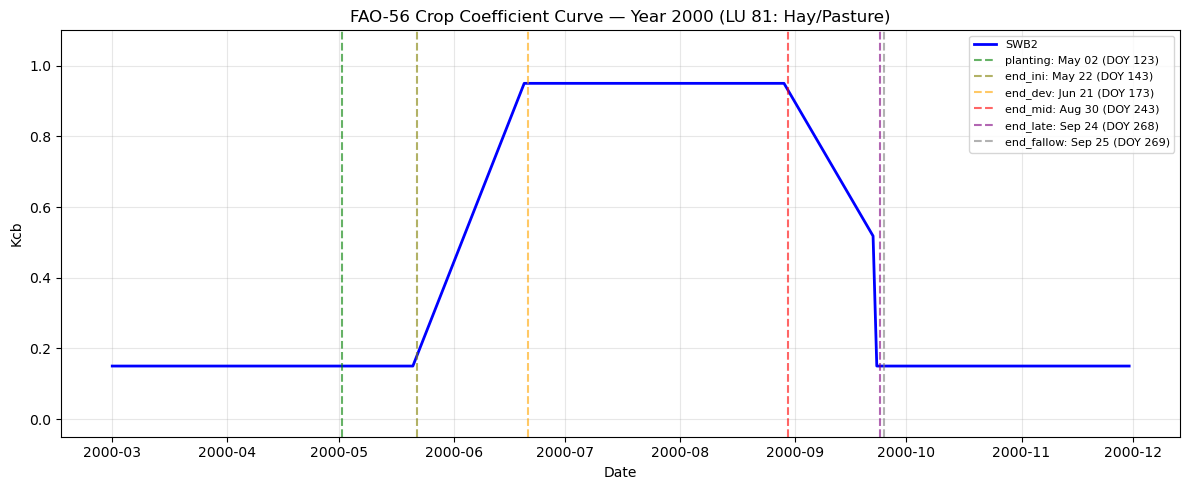

In [8]:
# Focus on year 2000
mask = (swb_df['date'] >= '2000-03-01') & (swb_df['date'] <= '2000-11-30')
sub = swb_df[mask]

# Compute stage dates for 2000
planting_2000 = dt.date(2000, 1, 1) + dt.timedelta(days=PLANTING_DOY)
stages_2000 = compute_growth_stage_dates(planting_2000, L_INI, L_DEV, L_MID, L_LATE, L_FALLOW)

print('Python stage dates for 2000:')
for k, v in stages_2000.items():
    print(f'  {k:12s}: {v} (DOY {v.timetuple().tm_yday})')

# Check SWB2 logfile for Kcb date recalculation messages
print('\n--- SWB2 logfile Kcb curve messages: ---')
logfiles = sorted(logfile_dir.glob('SWB_LOGFILE__*_DEBUG.md'))
if logfiles:
    with open(logfiles[-1]) as lf:
        for line in lf:
            # if 'Updating Kcb' in line or ('81' in line and 'Kcb' in line):
            if ('81' in line and 'Kcb' in line):
                print(line.rstrip())

# Show the transition region around end_ini for year 2000
trans_mask = (swb_df['date'] >= '2000-05-19') & (swb_df['date'] <= '2000-05-27')
trans_idx = np.where(trans_mask)[0]
print('\nSWB2 Kcb around end_ini (2000):')
for i in trans_idx:
    print(f'  {swb_df["date"].iloc[i].date()}  SWB2={swb_df["crop_coefficient_kcb"].iloc[i]:.4f}  Py={py_kcb[i]:.4f}')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sub['date'], sub['crop_coefficient_kcb'], 'b-', linewidth=2, label='SWB2')

# Mark stage boundaries
colors = {'planting': 'green', 'end_ini': 'olive', 'end_dev': 'orange',
           'end_mid': 'red', 'end_late': 'purple', 'end_fallow': 'gray'}
for name, date_val in stages_2000.items():
    ax.axvline(pd.Timestamp(date_val), color=colors[name], linestyle='--', alpha=0.6,
              label=f'{name}: {date_val.strftime("%b %d")} (DOY {date_val.timetuple().tm_yday})')

ax.set_xlabel('Date')
ax.set_ylabel('Kcb')
ax.set_title('FAO-56 Crop Coefficient Curve — Year 2000 (LU 81: Hay/Pasture)')
ax.legend(loc='upper right', fontsize=8)
ax.set_ylim(-0.05, 1.1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Quantitative assessment

In [9]:
print("=== Kcb Comparison ===")
print(f"  Total days: {len(diff)}")
print(f"  Days with exact match (diff < 0.001): {(np.abs(diff) < 0.001).sum()}")
print(f"  Max absolute difference: {np.abs(diff).max():.6f}")
print(f"  Mean absolute difference: {np.abs(diff).mean():.6f}")
print(f"\n  SWB2 Kcb range: {swb_df['crop_coefficient_kcb'].min():.4f} to {swb_df['crop_coefficient_kcb'].max():.4f}")
print(f"  Python Kcb range: {py_kcb.min():.4f} to {py_kcb.max():.4f}")

# Show any days with significant mismatch
mismatch = np.abs(diff) > 0.01
if mismatch.any():
    print(f"\n  Days with |diff| > 0.01: {mismatch.sum()}")
    print("  First 10 mismatches:")
    idx = np.where(mismatch)[0][:10]
    for i in idx:
        print(f"    {swb_df['date'].iloc[i].date()}: SWB2={swb_df['crop_coefficient_kcb'].iloc[i]:.4f}  Py={py_kcb[i]:.4f}")
else:
    print("\n  All days match within tolerance of 0.01.")

=== Kcb Comparison ===
  Total days: 2557
  Days with exact match (diff < 0.001): 2557
  Max absolute difference: 0.000000
  Mean absolute difference: 0.000000

  SWB2 Kcb range: 0.1500 to 0.9500
  Python Kcb range: 0.1500 to 0.9500

  All days match within tolerance of 0.01.


## Per-year growth stage dates: SWB2 vs Python

Compare the growth stage dates from the SWB2 DEBUG logfile against the Python-computed dates. SWB2 prints initial dates under `## Crop Kcb Curve Summary ##` and yearly updates under `## Updated Crop Kcb Curve Summary ##`.

In [10]:
# Parse SWB2 DEBUG logfile for Kcb curve dates (LU code 81)
logfiles = sorted(logfile_dir.glob('SWB_LOGFILE__*_DEBUG.md'))
swb2_stage_lines = []
if logfiles:
    with open(logfiles[-1]) as lf:
        for line in lf:
            if ' 81 ' in line and '|' in line and 'doy' in line and ('200' in line or '199' in line):
                swb2_stage_lines.append(line.rstrip())

print('SWB2 Kcb curve dates for LU code 81 (from DEBUG logfile):')
print()
for line in swb2_stage_lines:
    print(line)

SWB2 Kcb curve dates for LU code 81 (from DEBUG logfile):

| 81 | 1999-05-02 (doy:122) | 1999-05-22 |  (doy:142) | 1999-06-21 |  (doy:172) | 1999-08-30 |  (doy:242) | 1999-09-24 |  (doy:267) | 1999-09-25 (doy:268) |
| 81 | 2000-05-01 (doy:122) | 2000-05-21 |  (doy:142) | 2000-06-20 |  (doy:172) | 2000-08-29 |  (doy:242) | 2000-09-23 |  (doy:267) | 2000-09-24 (doy:268) |
| 81 | 2001-05-02 (doy:122) | 2001-05-22 |  (doy:142) | 2001-06-21 |  (doy:172) | 2001-08-30 |  (doy:242) | 2001-09-24 |  (doy:267) | 2001-09-25 (doy:268) |
| 81 | 2002-05-02 (doy:122) | 2002-05-22 |  (doy:142) | 2002-06-21 |  (doy:172) | 2002-08-30 |  (doy:242) | 2002-09-24 |  (doy:267) | 2002-09-25 (doy:268) |
| 81 | 2003-05-02 (doy:122) | 2003-05-22 |  (doy:142) | 2003-06-21 |  (doy:172) | 2003-08-30 |  (doy:242) | 2003-09-24 |  (doy:267) | 2003-09-25 (doy:268) |
| 81 | 2004-05-01 (doy:122) | 2004-05-21 |  (doy:142) | 2004-06-20 |  (doy:172) | 2004-08-29 |  (doy:242) | 2004-09-23 |  (doy:267) | 2004-09-24 (doy:268) |

In [11]:
# Python computed stage dates for each year
print('Python growth stage dates by year (LU code 81):')
print(f'{"Year":>5} {"Planting":>16} {"End ini":>16} {"End dev":>16} {"End mid":>16} {"End late":>16} {"End fallow":>16}')
print('-' * 105)

planting = dt.date(1999, 1, 1) + dt.timedelta(days=PLANTING_DOY - 1)
stages = compute_growth_stage_dates(planting, L_INI, L_DEV, L_MID, L_LATE, L_FALLOW)

def fmt_date_doy(d):
    return f'{d} (doy:{d.timetuple().tm_yday:3d})'

for year in range(1999, 2006):
    print(f'{year:5d} {fmt_date_doy(stages["planting"]):>16} {fmt_date_doy(stages["end_ini"]):>16} '
          f'{fmt_date_doy(stages["end_dev"]):>16} {fmt_date_doy(stages["end_mid"]):>16} '
          f'{fmt_date_doy(stages["end_late"]):>16} {fmt_date_doy(stages["end_fallow"]):>16}')
    
    # Advance to next year (mimicking SWB2's update_growth_stage_dates logic)
    next_planting = dt.date(year + 1, 1, 1) + dt.timedelta(days=PLANTING_DOY - 1)
    stages = compute_growth_stage_dates(next_planting, L_INI, L_DEV, L_MID, L_LATE, L_FALLOW)

Python growth stage dates by year (LU code 81):
 Year         Planting          End ini          End dev          End mid         End late       End fallow
---------------------------------------------------------------------------------------------------------
 1999 1999-05-02 (doy:122) 1999-05-22 (doy:142) 1999-06-21 (doy:172) 1999-08-30 (doy:242) 1999-09-24 (doy:267) 1999-09-25 (doy:268)
 2000 2000-05-01 (doy:122) 2000-05-21 (doy:142) 2000-06-20 (doy:172) 2000-08-29 (doy:242) 2000-09-23 (doy:267) 2000-09-24 (doy:268)
 2001 2001-05-02 (doy:122) 2001-05-22 (doy:142) 2001-06-21 (doy:172) 2001-08-30 (doy:242) 2001-09-24 (doy:267) 2001-09-25 (doy:268)
 2002 2002-05-02 (doy:122) 2002-05-22 (doy:142) 2002-06-21 (doy:172) 2002-08-30 (doy:242) 2002-09-24 (doy:267) 2002-09-25 (doy:268)
 2003 2003-05-02 (doy:122) 2003-05-22 (doy:142) 2003-06-21 (doy:172) 2003-08-30 (doy:242) 2003-09-24 (doy:267) 2003-09-25 (doy:268)
 2004 2004-05-01 (doy:122) 2004-05-21 (doy:142) 2004-06-20 (doy:172) 2004-08-2

## Summary

This test demonstrates that the SWB2 date-based FAO-56 crop coefficient curve construction is consistent with the Python reimplementation. Key aspects verified:

1. **Growth stage date computation** — Planting date + stage lengths correctly define the trapezoidal Kcb curve endpoints.
2. **Linear interpolation** — During development (ini→dev) and late (mid→end) stages, Kcb is linearly interpolated.
3. **Plateau** — During the mid-season stage, Kcb equals kcb_mid.
4. **Dormancy** — Before planting and after the late stage, Kcb returns to kcb_min.
5. **Multi-year cycling** — The Kcb curve resets correctly at the end of each fallow period.